In [17]:
##Import Library
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
#Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
 
import joblib
 
RANDOM_STATE = 42

**Load datasets**

In [57]:
##Reading the dataset
DATA_FILE_1 = pd.read_csv("Crop Yeild Data.csv")
DATA_FILE_2 = pd.read_csv("Custom_Crops_yield_Historical_Dataset.csv")

**Display the Dataset1**

In [19]:
DATA_FILE_1

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


**Filling the Missing Values(Audit)**

In [24]:
##Checking for the null values
print(DATA_FILE_1.info())
print("\nMissing values:")
print(DATA_FILE_1.isnull().sum())
print("\nDuplicate rows:", DATA_FILE_1.duplicated().sum())
print("\nRegression target statistics:")
print(DATA_FILE_1["annual_rainfall"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   crop             19689 non-null  object 
 1   crop_year        19689 non-null  int64  
 2   season           19689 non-null  object 
 3   state            19689 non-null  object 
 4   area             19689 non-null  float64
 5   production       19689 non-null  int64  
 6   annual_rainfall  19689 non-null  float64
 7   fertilizer       19689 non-null  float64
 8   pesticide        19689 non-null  float64
 9   yield            19689 non-null  float64
 10  avg_temperature  19689 non-null  float64
 11  max_temperature  19689 non-null  float64
 12  min_temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB
None

Missing values:
crop               0
crop_year          0
season             0
state              0
area               0
production  

**Dataset 1 EDA for Regression**

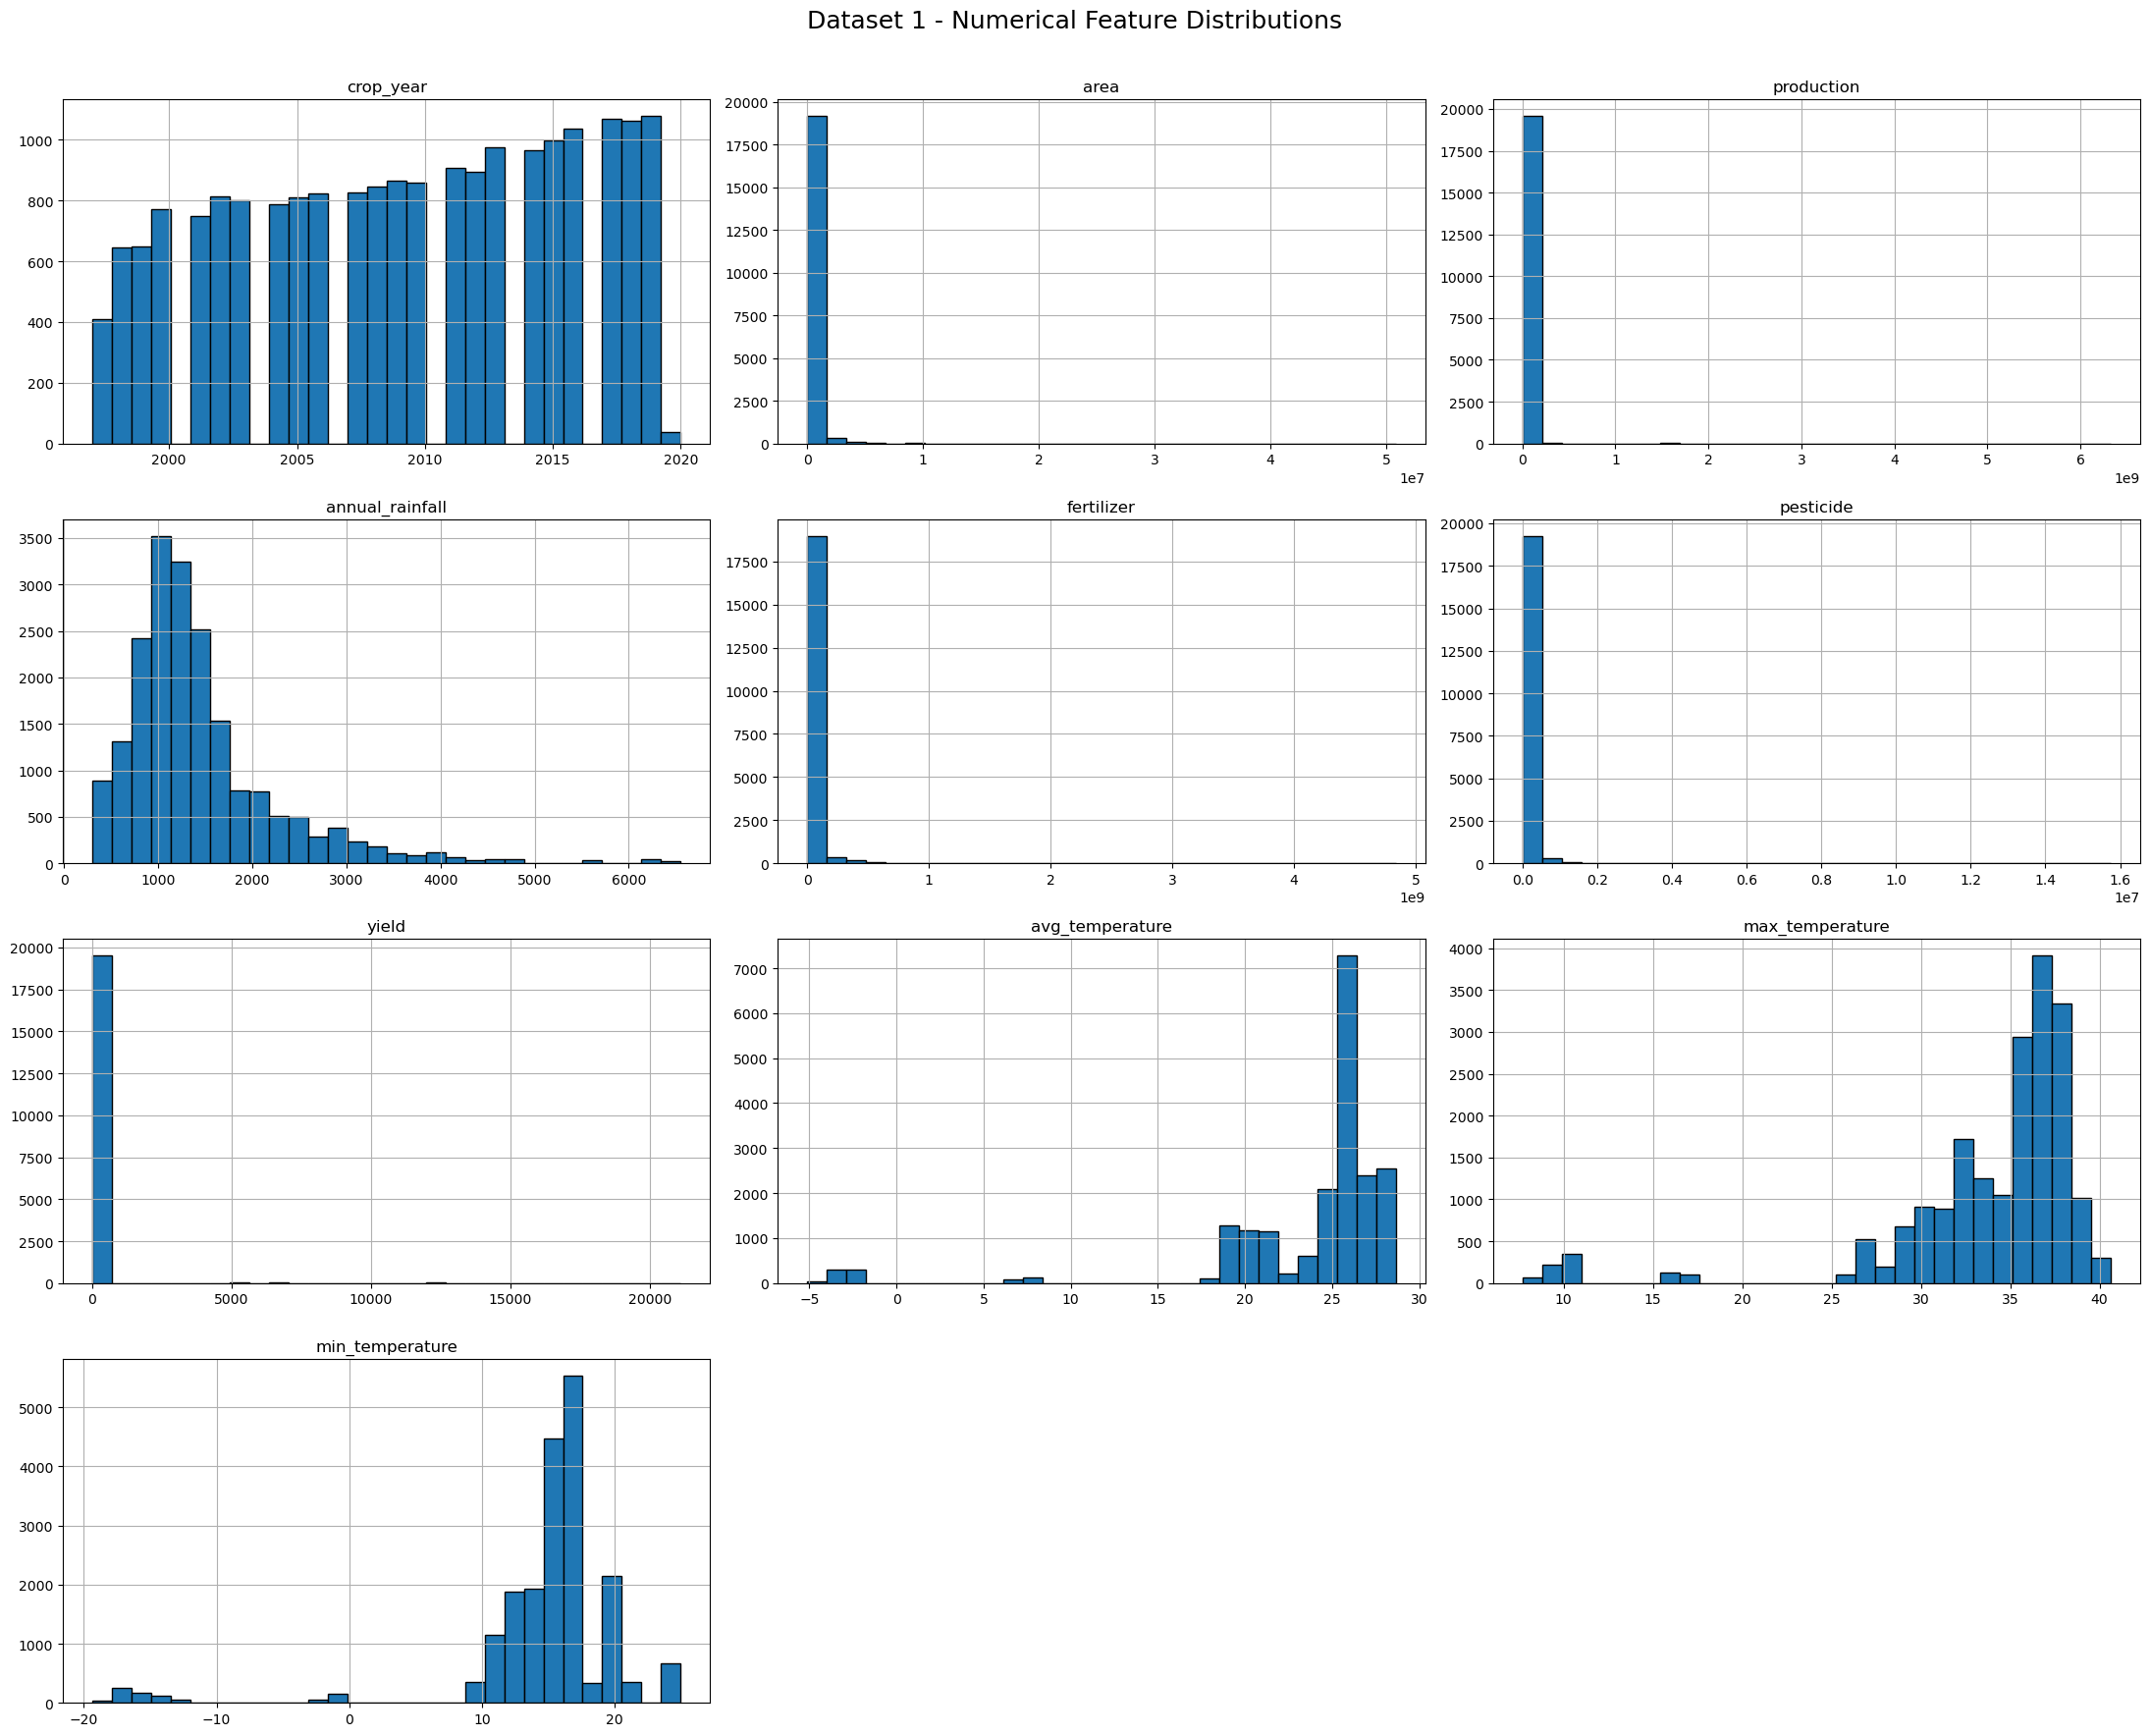

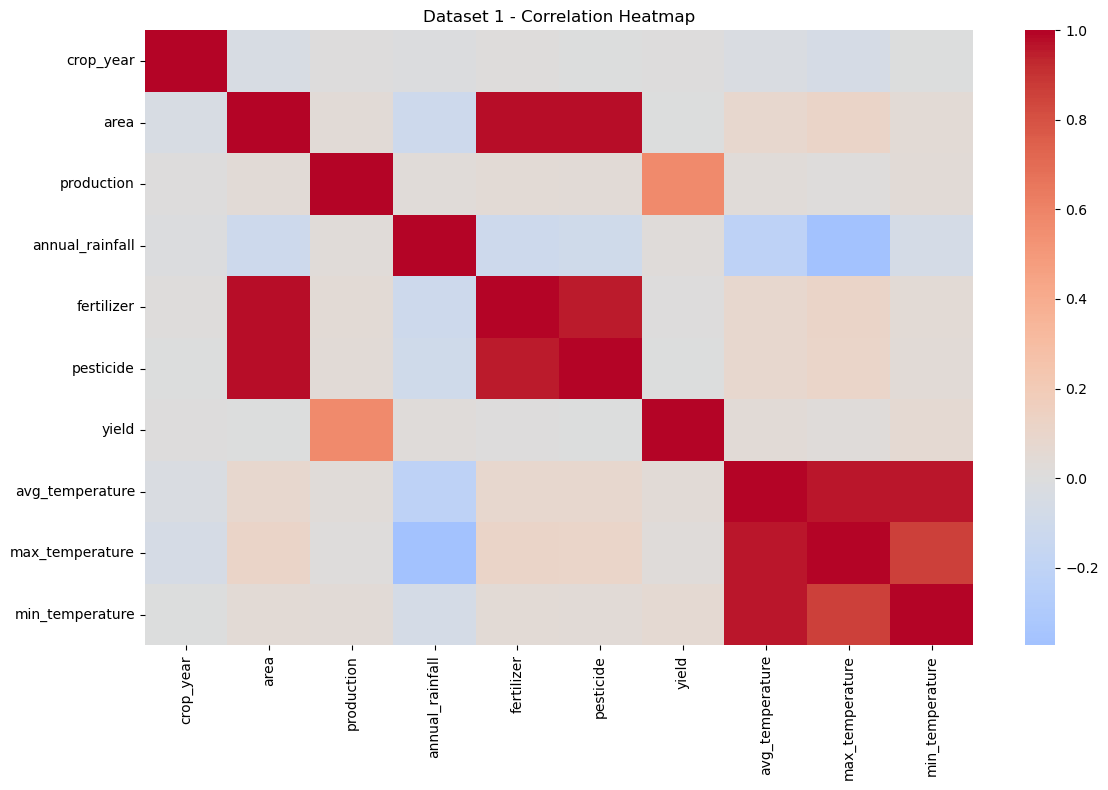

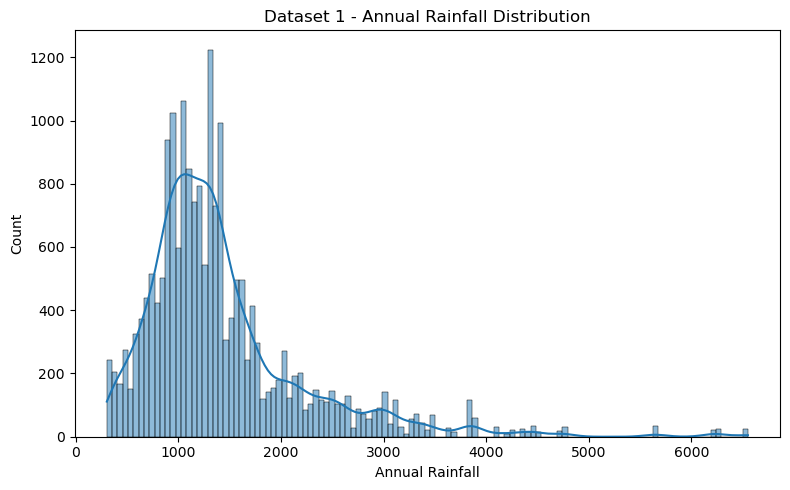

In [26]:
numeric_cols_reg_eda = DATA_FILE_1.select_dtypes(include=np.number).columns.tolist()

DATA_FILE_1[numeric_cols_reg_eda].hist(
    bins=30, figsize=(22, 18), edgecolor="black"
)
plt.suptitle("Dataset 1 - Numerical Feature Distributions", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(DATA_FILE_1[numeric_cols_reg_eda].corr(), cmap="coolwarm", center=0)
plt.title("Dataset 1 - Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(DATA_FILE_1["annual_rainfall"].dropna(), kde=True)
plt.title("Dataset 1 - Annual Rainfall Distribution")
plt.xlabel("Annual Rainfall")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Dataset 1 feature-target scatter plots**

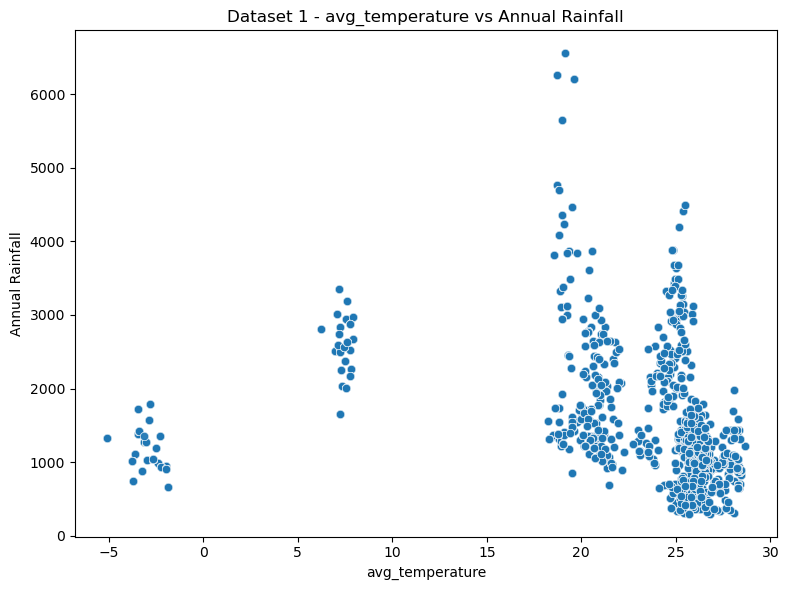

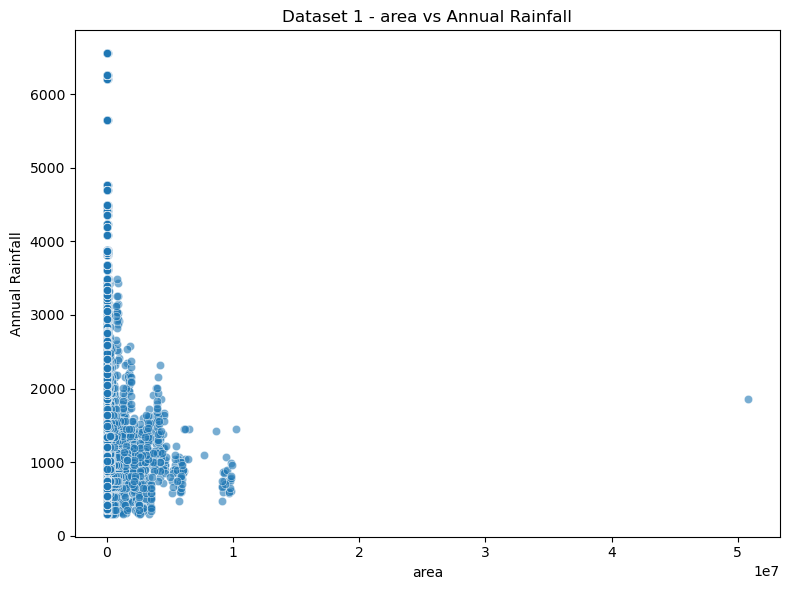

In [27]:
scatter_features = ["avg_temperature", "area"]

for feature in scatter_features:
    if feature in DATA_FILE_1.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=DATA_FILE_1, x=feature, y="annual_rainfall", alpha=0.6)
        plt.title(f"Dataset 1 - {feature} vs Annual Rainfall")
        plt.xlabel(feature)
        plt.ylabel("Annual Rainfall")
        plt.tight_layout()
        plt.show()


**KEEP: Prepare Dataset 1 for Regression**

In [28]:
# Target = annual_rainfall
# Do not use annual_rainfall or yield as input features because uncertainity in that data.
regression_drop = ["annual_rainfall", "yield"]
regression_drop = [c for c in regression_drop if c in DATA_FILE_1.columns]

X_reg = DATA_FILE_1.drop(columns=regression_drop).copy()
y_reg = DATA_FILE_1["annual_rainfall"].copy()

# Remove high-cardinality identifiers
id_columns = ["dist_code", "state_code"]
id_columns = [c for c in id_columns if c in X_reg.columns]
X_reg = X_reg.drop(columns=id_columns)

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

Regression X shape: (19689, 11)
Regression y shape: (19689,)


**Dataset 1 feature engineering**

In [30]:
# Example engineered feature
if "fertilizer" in X_reg.columns and "area" in X_reg.columns:
    X_reg["fertilizer_per_area"] = X_reg["fertilizer"] / X_reg["area"].replace(0, np.nan)

print("Regression features after feature engineering:")
print(X_reg.columns.tolist())


Regression features after feature engineering:
['crop', 'crop_year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'avg_temperature', 'max_temperature', 'min_temperature', 'fertilizer_per_area']


**Dataset 1 train-test split and preprocessing**

In [31]:
numeric_features_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", numeric_transformer_reg, numeric_features_reg),
    ("cat", categorical_transformer_reg, categorical_features_reg)
])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print("Regression training:", X_train_reg.shape)
print("Regression testing :", X_test_reg.shape)


Regression training: (15751, 12)
Regression testing : (3938, 12)


**Train all 10 required Regression algorithms**

In [33]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet Regression": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "SVR": SVR(C=1.0, kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

regression_results = []
regression_predictions = {}
regression_pipelines = {}

for name, model in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_reg),
        ("model", model)
    ])

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    regression_results.append([
        name,
        r2_score(y_test_reg, predictions),
        np.sqrt(mean_squared_error(y_test_reg, predictions)),
        mean_absolute_error(y_test_reg, predictions)
    ])

    regression_predictions[name] = predictions
    regression_pipelines[name] = pipeline


**Polynomial Regression**

In [34]:
polynomial_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

polynomial_pipeline.fit(X_train_reg, y_train_reg)
y_pred_poly = polynomial_pipeline.predict(X_test_reg)

regression_results.append([
    "Polynomial Regression",
    r2_score(y_test_reg, y_pred_poly),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)),
    mean_absolute_error(y_test_reg, y_pred_poly)
])

regression_predictions["Polynomial Regression"] = y_pred_poly
regression_pipelines["Polynomial Regression"] = polynomial_pipeline


**Regression comparison table**

In [35]:
regression_results_df = pd.DataFrame(
    regression_results,
    columns=["Model", "R2", "RMSE", "MAE"]
).sort_values("R2", ascending=False).reset_index(drop=True)

display(regression_results_df)


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.999992,2.314570,0.279749
1,Gradient Boosting Regressor,0.936129,208.273145,154.462647
2,Polynomial Regression,0.892921,269.670586,169.052448
3,Ridge Regression,0.865499,302.233686,188.088779
4,Lasso Regression,0.865493,302.241202,188.198264
5,Linear Regression,0.865426,302.316008,188.313509
6,KNN Regressor,0.857218,311.399450,205.879839
7,ElasticNet Regression,0.849753,319.435525,201.689222
8,Decision Tree Regressor,0.800592,368.003640,263.943958
9,SVR,0.195832,739.016778,449.557969


**Tune at least two Regression models**

In [36]:
ridge_grid = GridSearchCV(
    Pipeline([("preprocessor", preprocessor_reg), ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train_reg, y_train_reg)

rf_grid = GridSearchCV(
    Pipeline([("preprocessor", preprocessor_reg), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20]},
    cv=5, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train_reg, y_train_reg)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV R2:", rf_grid.best_score_)

Best Ridge parameters: {'model__alpha': 0.1}
Best Ridge CV R2: 0.8603422930531834
Best Random Forest parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Best Random Forest CV R2: 0.999950436446416


**5-fold CV for the two best Regression models**

In [37]:
top_two_regression = regression_results_df.head(2)["Model"].tolist()

cv_rows = []
for name in top_two_regression:
    scores = cross_val_score(
        regression_pipelines[name],
        X_reg, y_reg, cv=5, scoring="r2", n_jobs=-1
    )
    cv_rows.append([name, scores.mean(), scores.std()])

regression_cv_df = pd.DataFrame(cv_rows, columns=["Model", "Mean CV R2", "Std CV R2"])
display(regression_cv_df)


,Model,Mean CV R2,Std CV R2
0,Random Forest Regressor,0.674283,0.122054
1,Gradient Boosting Regressor,0.742076,0.093015


**Best Regression plots**

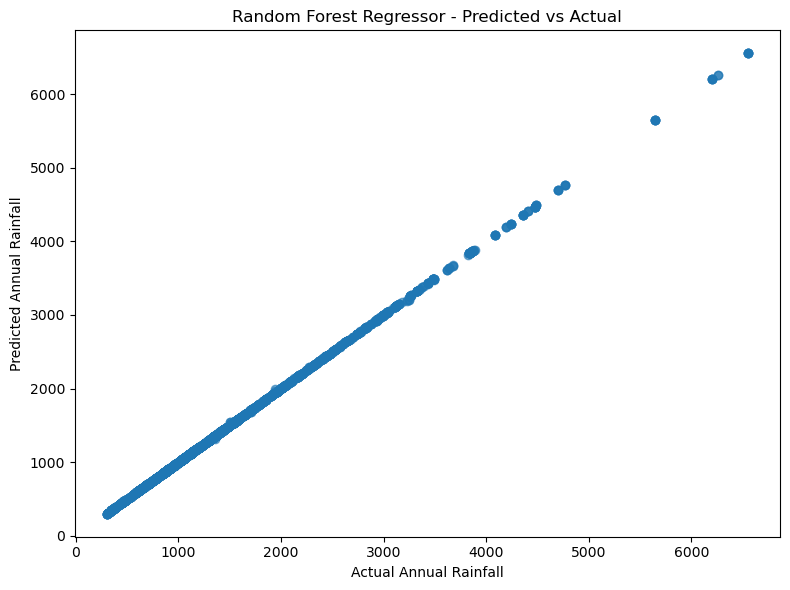

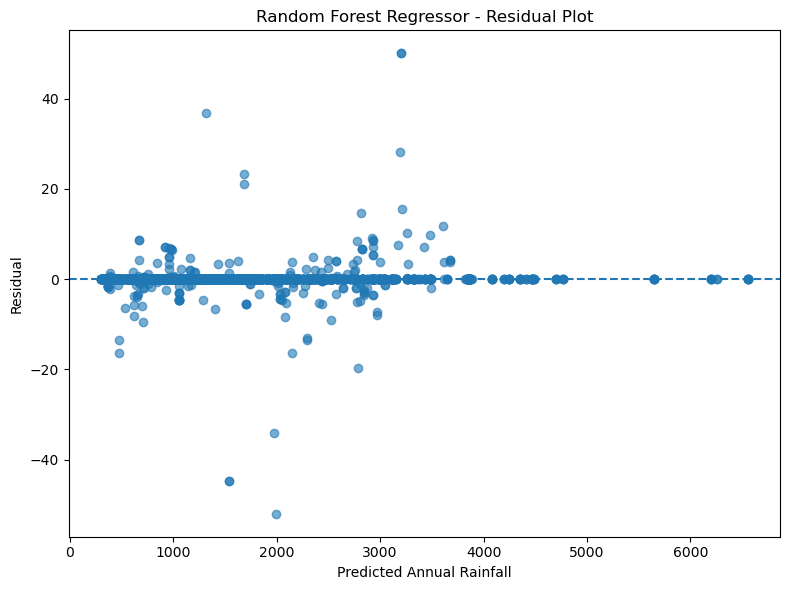

In [38]:
best_regression_name = regression_results_df.iloc[0]["Model"]
best_reg_predictions = regression_predictions[best_regression_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, best_reg_predictions, alpha=0.6)
plt.xlabel("Actual Annual Rainfall")
plt.ylabel("Predicted Annual Rainfall")
plt.title(f"{best_regression_name} - Predicted vs Actual")
plt.tight_layout()
plt.show()

residuals = y_test_reg - best_reg_predictions
plt.figure(figsize=(8, 6))
plt.scatter(best_reg_predictions, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Annual Rainfall")
plt.ylabel("Residual")
plt.title(f"{best_regression_name} - Residual Plot")
plt.tight_layout()
plt.show()


**Display Dataset 2**

In [58]:
DATA_FILE_2

,record_id,plant_type,habitat,season,air_humidity_pct,soil_humidity_pct,ethylene_ppm,co2_ppm,o2_ppm,ldr_on_plant,leaf_color_index,temperature_c,health_score,health_class
0,php_00001,rose,garden,winter,86.3,55.9,1.145,725.9,19.62,559,42.5,34.1,60,moderate_stress
1,php_00002,pothos,indoor,spring,55.3,29.8,1.102,1202.2,19.11,58,51.6,37.5,52,high_stress
2,php_00003,lettuce,greenhouse,autumn,92.6,10.3,1.042,1003.2,18.31,682,74.4,8.7,35,high_stress
3,php_00004,pothos,shade_house,autumn,62.0,40.3,0.700,566.3,20.43,460,57.7,29.8,92,healthy
4,php_00005,mint,indoor,spring,70.9,64.6,0.603,381.8,18.85,964,26.2,31.1,52,high_stress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,php_01996,lettuce,hydroponic,summer,27.5,86.5,1.906,684.1,20.25,69,88.7,35.4,37,high_stress
1996,php_01997,mint,greenhouse,spring,83.7,49.6,0.040,846.2,18.26,629,42.7,34.3,53,high_stress
1997,php_01998,rose,garden,monsoon,87.3,51.2,1.693,1198.2,19.46,96,25.1,33.8,28,high_stress
1998,php_01999,rose,garden,spring,73.5,60.3,2.305,699.1,18.75,547,93.5,25.4,69,moderate_stress


**Define Features and target**

In [60]:
# Target column
target_col_cls = "health_class"

# Remove ID and health_score
# health_score is removed to avoid target leakage
drop_columns_cls = [
    "record_id",
    "health_score"
]

# Features
X_cls = DATA_FILE_2.drop(
    columns=[target_col_cls] + drop_columns_cls
)

# Target
y_cls = DATA_FILE_2[target_col_cls]

print("Classification Features:")
print(X_cls.columns.tolist())

print("\nTarget Column:")
print(target_col_cls)

print("\nTarget Distribution:")
print(y_cls.value_counts())

Classification Features:
['plant_type', 'habitat', 'season', 'air_humidity_pct', 'soil_humidity_pct', 'ethylene_ppm', 'co2_ppm', 'o2_ppm', 'ldr_on_plant', 'leaf_color_index', 'temperature_c']

Target Column:
health_class

Target Distribution:
health_class
moderate_stress    929
high_stress        831
healthy            240
Name: count, dtype: int64


**Dataset 2 audit for Classification**

In [62]:
print(DATA_FILE_2.info())
print("\nMissing values:")
print(DATA_FILE_2.isnull().sum())
print("\nDuplicate rows:", DATA_FILE_2.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_id          2000 non-null   object 
 1   plant_type         2000 non-null   object 
 2   habitat            2000 non-null   object 
 3   season             2000 non-null   object 
 4   air_humidity_pct   2000 non-null   float64
 5   soil_humidity_pct  2000 non-null   float64
 6   ethylene_ppm       2000 non-null   float64
 7   co2_ppm            2000 non-null   float64
 8   o2_ppm             2000 non-null   float64
 9   ldr_on_plant       2000 non-null   int64  
 10  leaf_color_index   2000 non-null   float64
 11  temperature_c      2000 non-null   float64
 12  health_score       2000 non-null   int64  
 13  health_class       2000 non-null   object 
dtypes: float64(7), int64(2), object(5)
memory usage: 218.9+ KB
None

Missing values:
record_id            0
plant_type      

**Train and Test split**

In [64]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])

Training samples: 1600
Testing samples: 400


**Dataset 2 EDA for Classification preprocessing**

In [65]:
numeric_features_cls = X_cls.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features_cls = X_cls.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features_cls)

print("\nCategorical Features:")
print(categorical_features_cls)


# Numerical preprocessing
numeric_transformer_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_transformer_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine both
preprocessor_cls = ColumnTransformer([
    ("num", numeric_transformer_cls, numeric_features_cls),
    ("cat", categorical_transformer_cls, categorical_features_cls)
])


Numerical Features:
['air_humidity_pct', 'soil_humidity_pct', 'ethylene_ppm', 'co2_ppm', 'o2_ppm', 'ldr_on_plant', 'leaf_color_index', 'temperature_c']

Categorical Features:
['plant_type', 'habitat', 'season']


**Train the 5  Classification algorithms**

In [67]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "KNN Classification": KNeighborsClassifier(
        n_neighbors=5
    ),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        random_state=RANDOM_STATE
    )
}
classification_results = []
classification_predictions = {}
classification_pipelines = {}
for name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_cls),
        ("model", model)
    ])
    # Train model
    pipeline.fit(
        X_train_cls,
        y_train_cls
    )
    # Make predictions
    predictions = pipeline.predict(
        X_test_cls
    )
    # Calculate metrics
    accuracy = accuracy_score(
        y_test_cls,
        predictions
    )
    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    # Store results
    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
    classification_predictions[name] = predictions
    classification_pipelines[name] = pipeline

**Classification comparison table**

In [68]:
classification_results_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)
classification_results_df = classification_results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(classification_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.7775,0.784912,0.7775,0.772181
1,Decision Tree Classifier,0.6325,0.642976,0.6325,0.633007
2,KNN Classification,0.6175,0.635871,0.6175,0.619336
3,Gaussian Naive Bayes,0.6025,0.606677,0.6025,0.597398
4,Logistic Regression,0.6000,0.599546,0.6000,0.591088


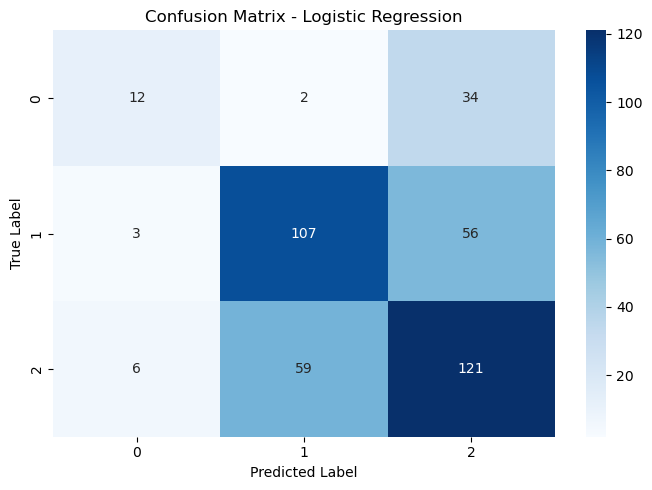

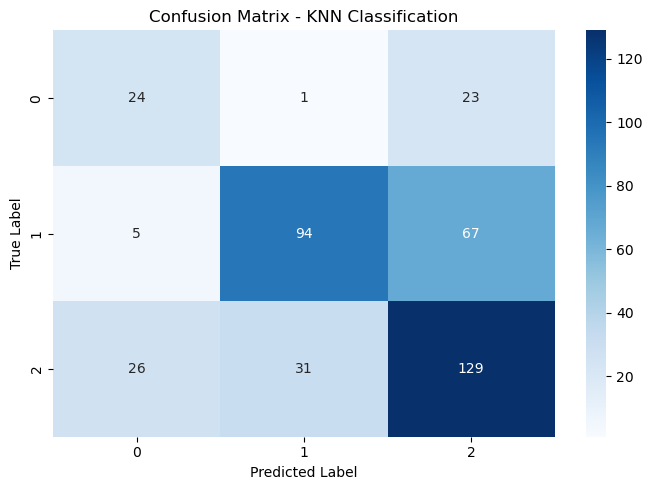

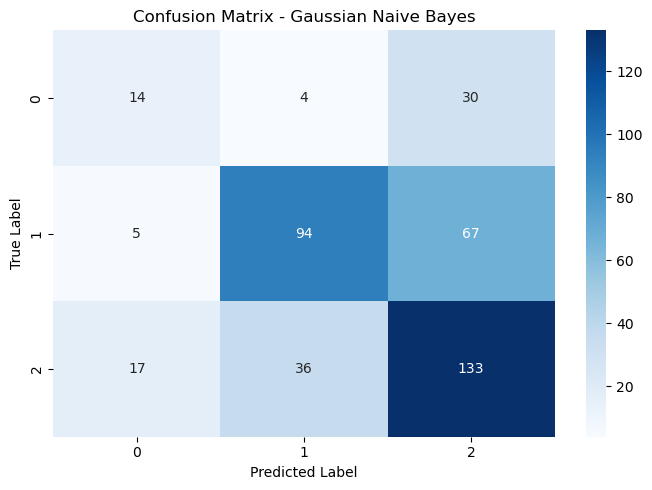

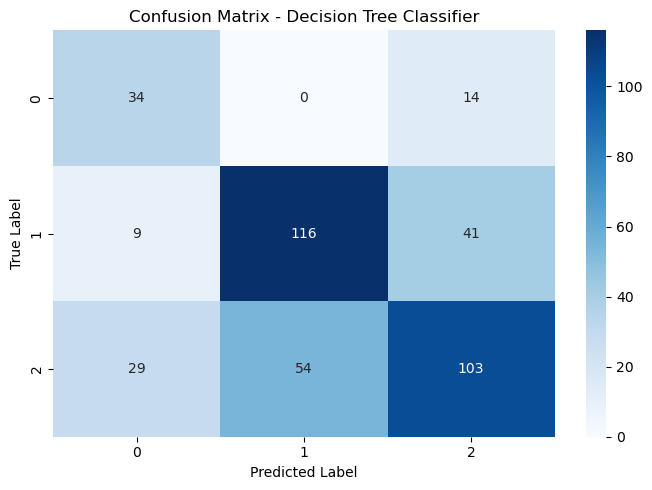

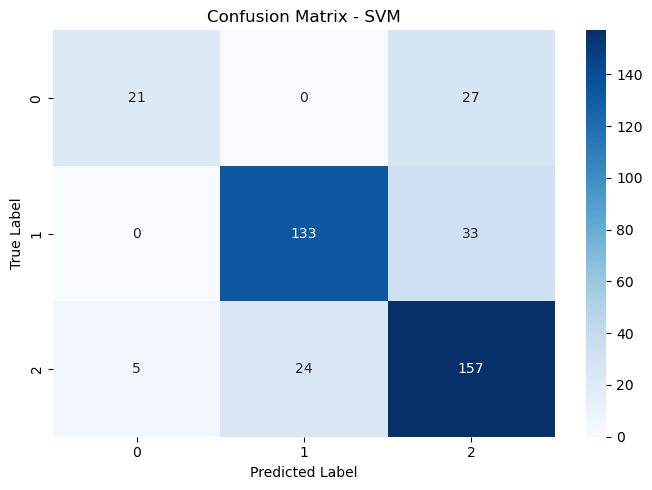

In [69]:
for name, predictions in classification_predictions.items():
    cm = confusion_matrix(
        y_test_cls,
        predictions
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()